# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Hospital Readmission Dataset](https://www.kaggle.com/datasets/mohamedasak/hospital-patient-readmission-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('hospital_readmission_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


## last Five row

In [4]:
df.tail()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
7995,P07996,2022-01-11,Winter,95,Female,East,COPD,6,9,Interventional,11,6,2,Medicare,Skilled Nursing,0.97,1
7996,P07997,2022-05-05,Spring,63,Female,East,Kidney Disease,4,7,Surgical,7,4,1,Medicaid,Home Health,0.94,1
7997,P07998,2021-08-26,Summer,43,Female,East,Diabetes,3,6,Medical,4,2,3,Uninsured,Home Health,0.79,1
7998,P07999,2021-04-20,Spring,86,Male,West,Sepsis,7,12,Interventional,12,5,3,Medicare,Skilled Nursing,0.97,1
7999,P08000,2021-06-12,Summer,93,Female,North,Kidney Disease,7,8,Conservative,10,6,3,Medicare,Skilled Nursing,0.97,1


## Shape of our dataset

In [5]:
df.shape

(8000, 17)

## List out all columns

In [6]:
df.columns

Index(['patient_id', 'admission_date', 'season', 'age', 'gender', 'region',
       'primary_diagnosis', 'comorbidities_count', 'length_of_stay',
       'treatment_type', 'medications_count', 'followup_visits_last_year',
       'prev_readmissions', 'insurance_type', 'discharge_disposition',
       'readmission_risk_score', 'label'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

patient_id                    object
admission_date                object
season                        object
age                            int64
gender                        object
region                        object
primary_diagnosis             object
comorbidities_count            int64
length_of_stay                 int64
treatment_type                object
medications_count              int64
followup_visits_last_year      int64
prev_readmissions              int64
insurance_type                object
discharge_disposition         object
readmission_risk_score       float64
label                          int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null   objec

## Check Null Value

In [9]:
df.isnull().sum()

patient_id                   0
admission_date               0
season                       0
age                          0
gender                       0
region                       0
primary_diagnosis            0
comorbidities_count          0
length_of_stay               0
treatment_type               0
medications_count            0
followup_visits_last_year    0
prev_readmissions            0
insurance_type               0
discharge_disposition        0
readmission_risk_score       0
label                        0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,age,comorbidities_count,length_of_stay,medications_count,followup_visits_last_year,prev_readmissions,readmission_risk_score,label
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000
mean,57.411625,4.318500,7.789125,7.475750,3.638125,1.57250,0.776937,0.772875
std,16.724388,1.358046,1.930252,2.287917,1.630415,0.89196,0.219885,0.419000
min,18.000000,1.000000,3.000000,2.000000,0.000000,0.00000,0.070000,0.000000
25%,46.000000,3.000000,6.000000,6.000000,2.000000,1.00000,0.630000,1.000000
50%,57.000000,4.000000,8.000000,8.000000,4.000000,1.00000,0.860000,1.000000
75%,69.000000,5.000000,9.000000,9.000000,4.000000,2.00000,0.970000,1.000000
max,95.000000,10.000000,15.000000,18.000000,10.000000,5.00000,0.970000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

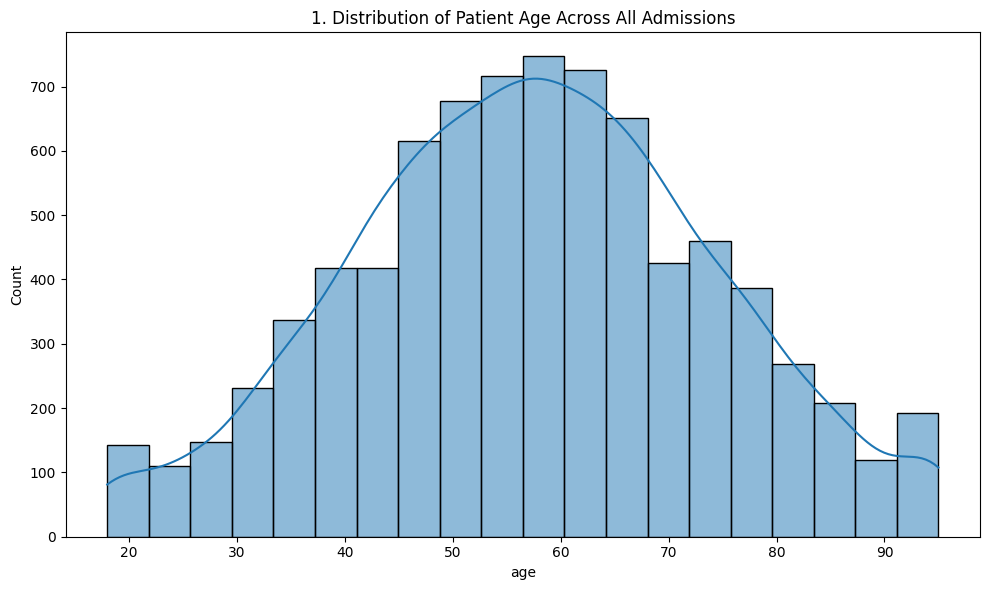

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Patient Age Across All Admissions')
show_fig()
plot_no += 1

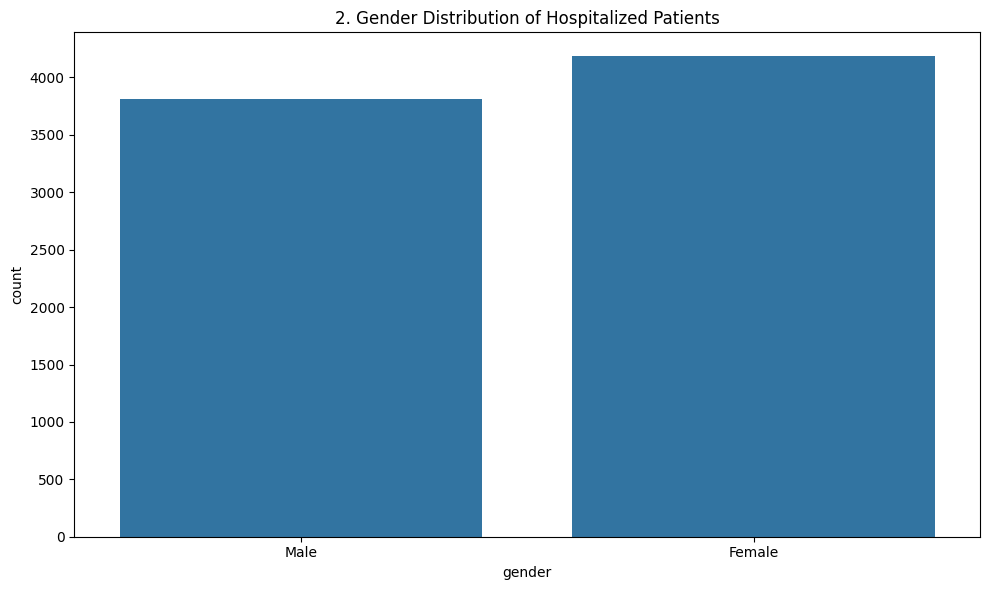

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='gender')
plt.title(f'{plot_no}. Gender Distribution of Hospitalized Patients')
show_fig()
plot_no += 1

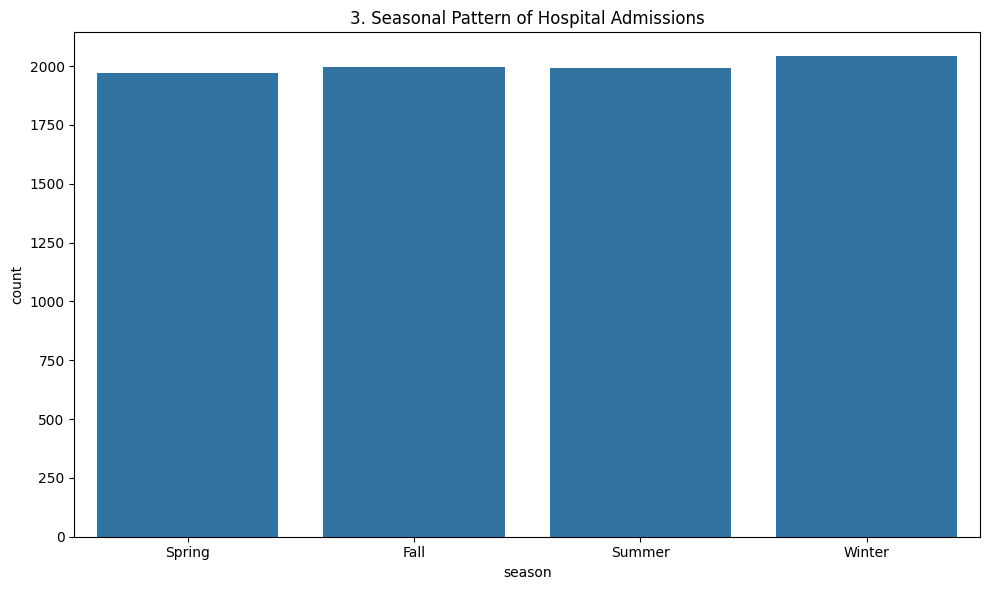

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='season')
plt.title(f'{plot_no}. Seasonal Pattern of Hospital Admissions')
show_fig()
plot_no += 1

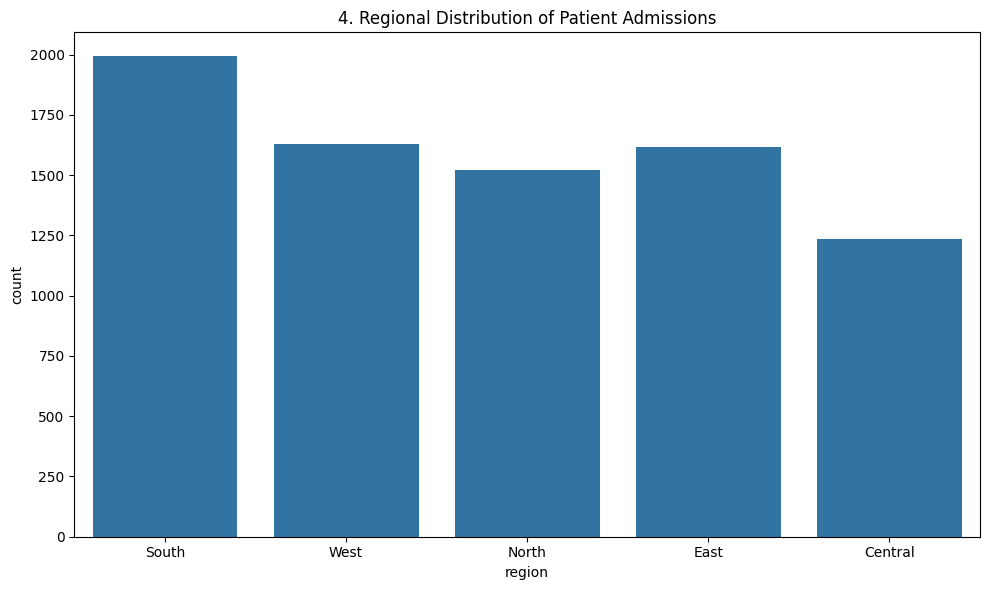

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='region')
plt.title(f'{plot_no}. Regional Distribution of Patient Admissions')
show_fig()
plot_no += 1

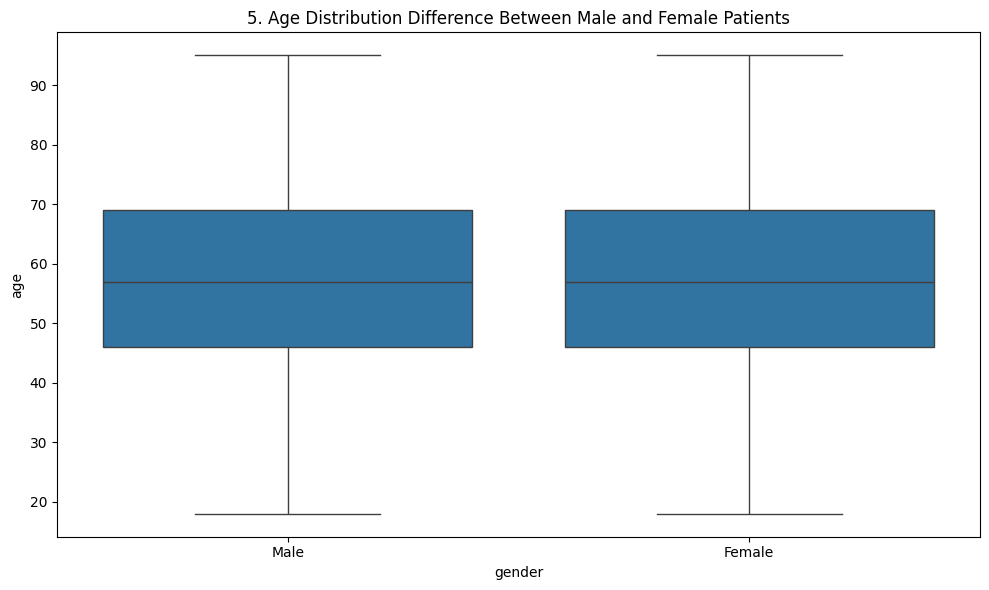

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='age')
plt.title(f'{plot_no}. Age Distribution Difference Between Male and Female Patients')
show_fig()
plot_no += 1

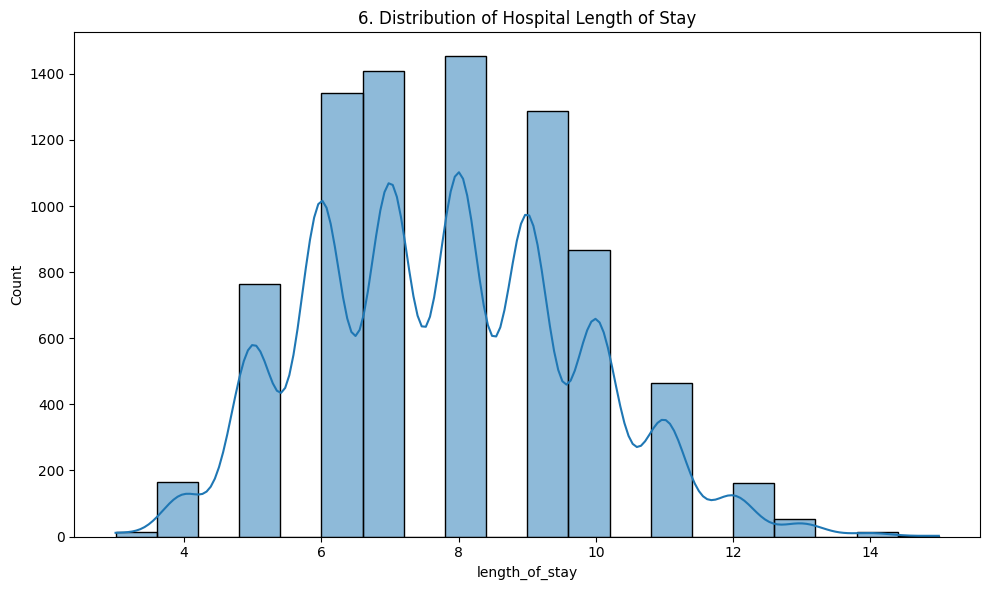

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['length_of_stay'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Hospital Length of Stay')
show_fig()
plot_no += 1

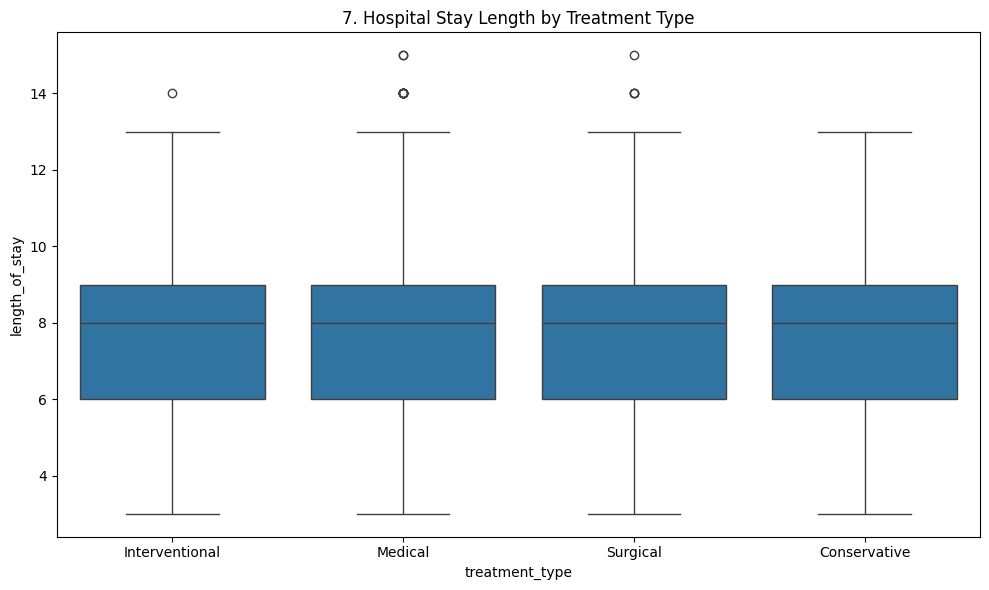

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='treatment_type', y='length_of_stay')
plt.title(f'{plot_no}. Hospital Stay Length by Treatment Type')
show_fig()
plot_no += 1

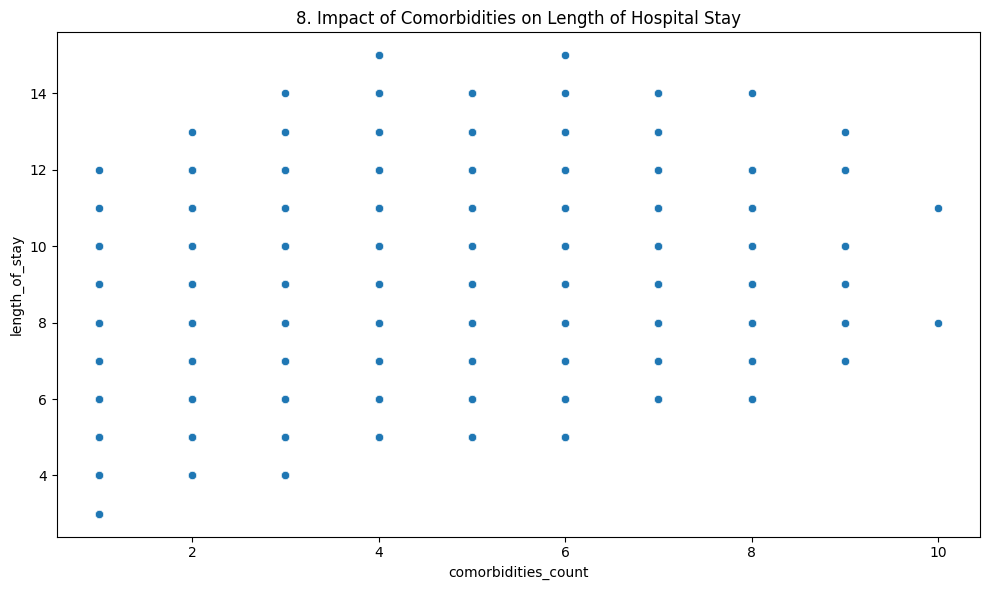

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='comorbidities_count', y='length_of_stay')
plt.title(f'{plot_no}. Impact of Comorbidities on Length of Hospital Stay')
show_fig()
plot_no += 1

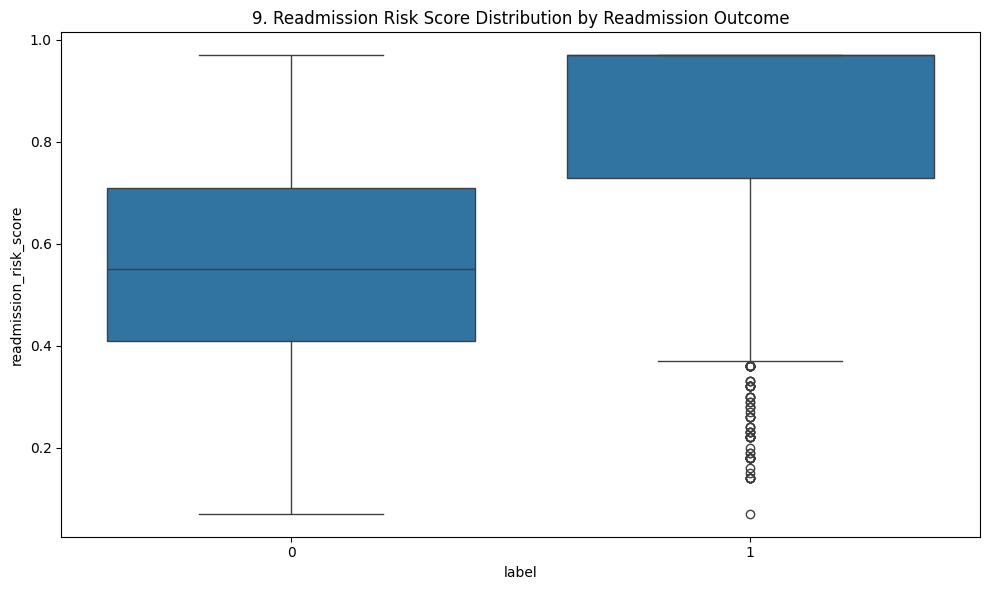

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='label', y='readmission_risk_score')
plt.title(f'{plot_no}. Readmission Risk Score Distribution by Readmission Outcome')
show_fig()
plot_no += 1

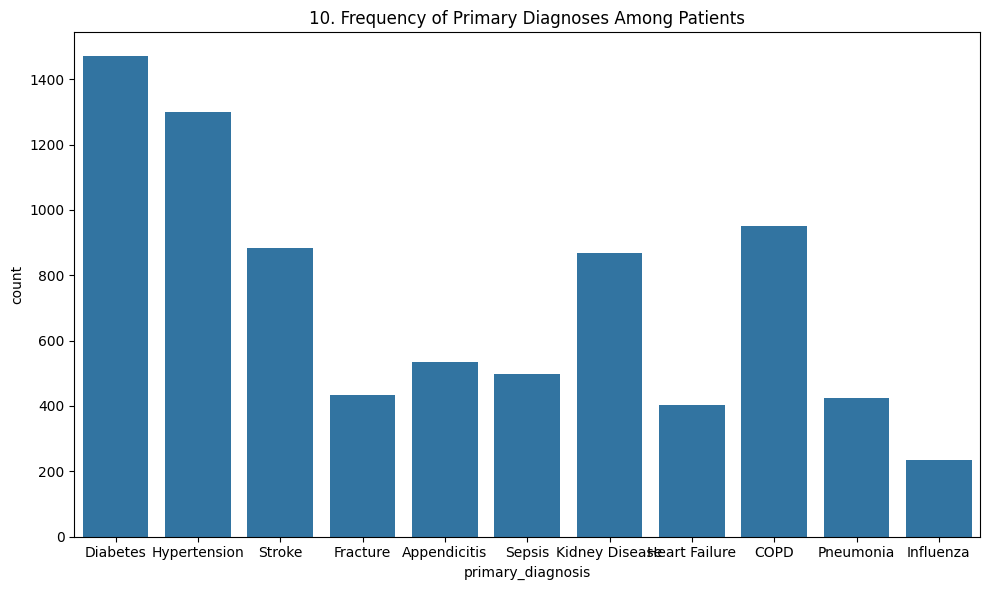

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='primary_diagnosis')
plt.title(f'{plot_no}. Frequency of Primary Diagnoses Among Patients')
show_fig()
plot_no += 1

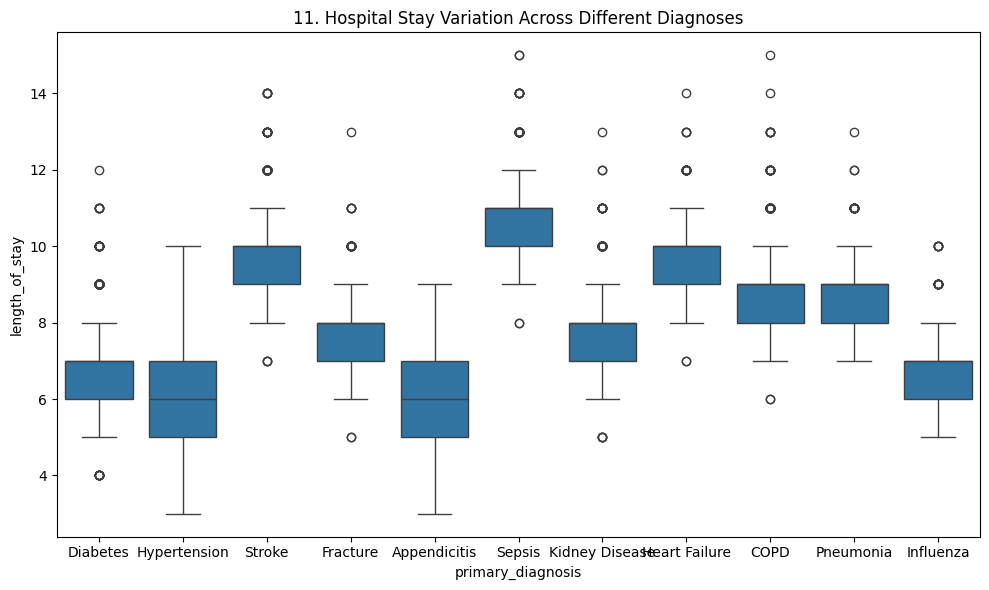

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='primary_diagnosis', y='length_of_stay')
plt.title(f'{plot_no}. Hospital Stay Variation Across Different Diagnoses')
show_fig()
plot_no += 1

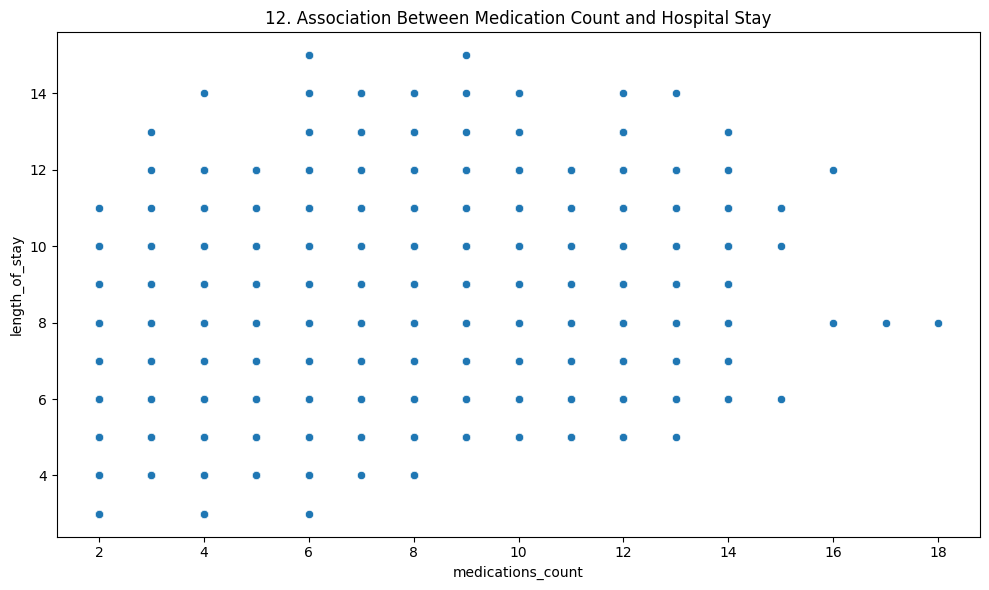

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='medications_count', y='length_of_stay')
plt.title(f'{plot_no}. Association Between Medication Count and Hospital Stay')
show_fig()
plot_no += 1

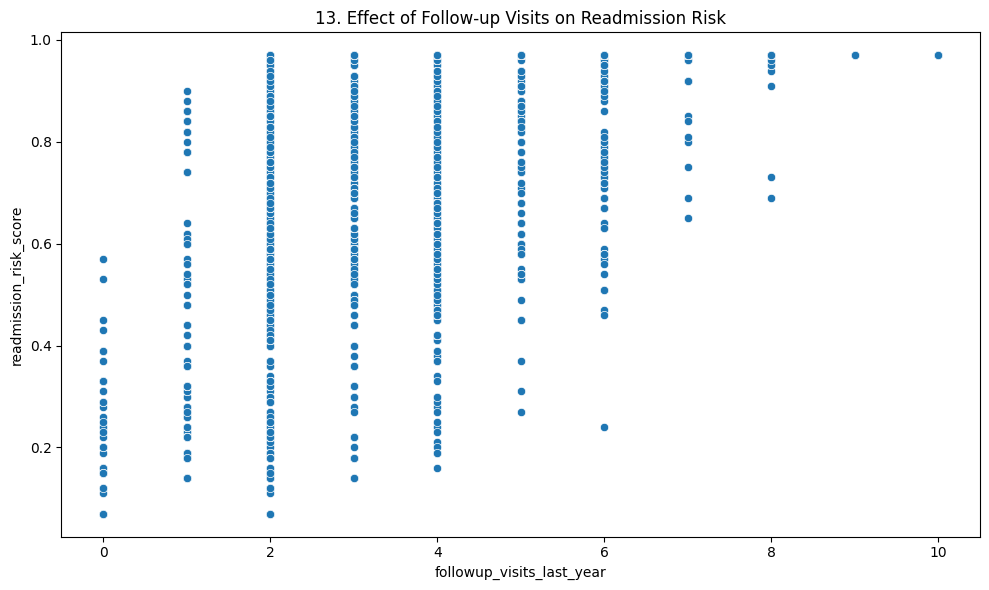

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='followup_visits_last_year', y='readmission_risk_score')
plt.title(f'{plot_no}. Effect of Follow-up Visits on Readmission Risk')
show_fig()
plot_no += 1

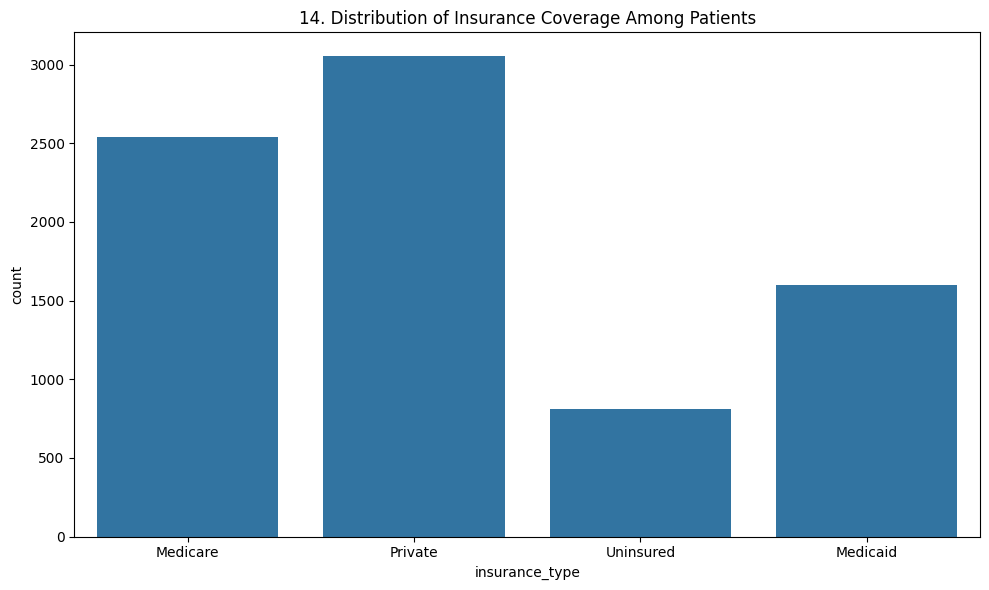

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='insurance_type')
plt.title(f'{plot_no}. Distribution of Insurance Coverage Among Patients')
show_fig()
plot_no += 1

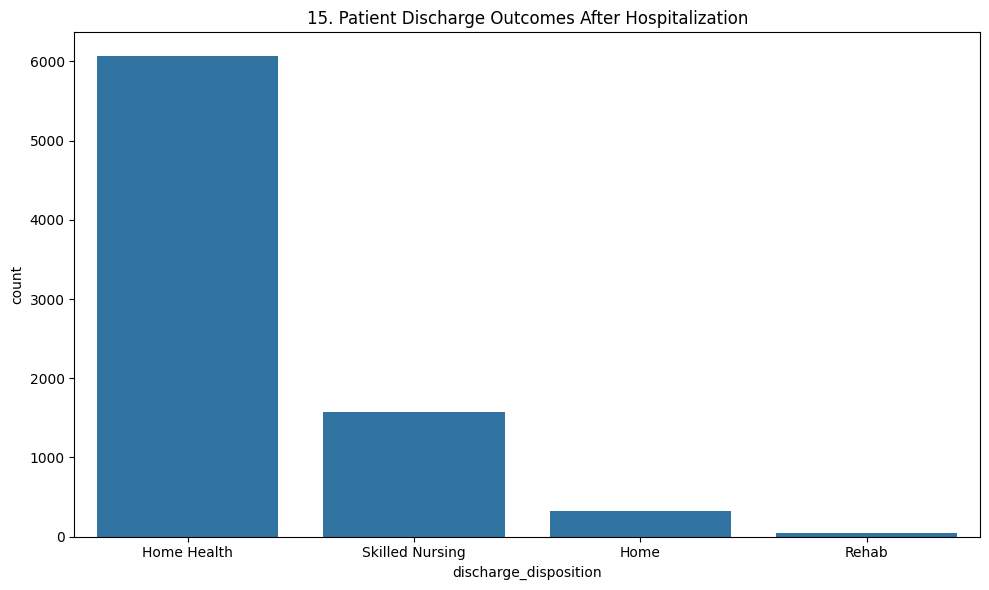

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='discharge_disposition')
plt.title(f'{plot_no}. Patient Discharge Outcomes After Hospitalization')
show_fig()
plot_no += 1

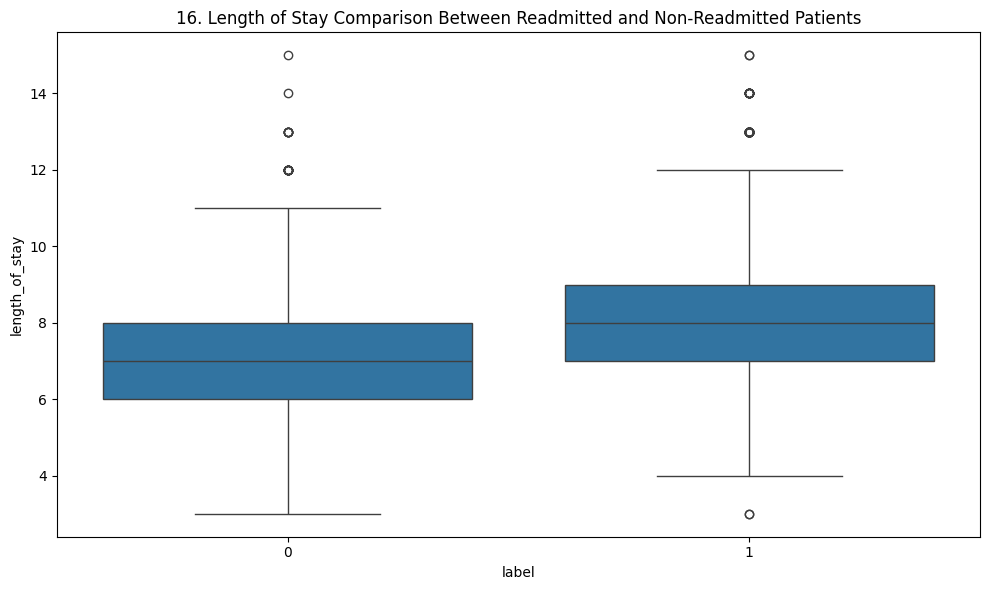

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='label', y='length_of_stay')
plt.title(f'{plot_no}. Length of Stay Comparison Between Readmitted and Non-Readmitted Patients')
show_fig()
plot_no += 1

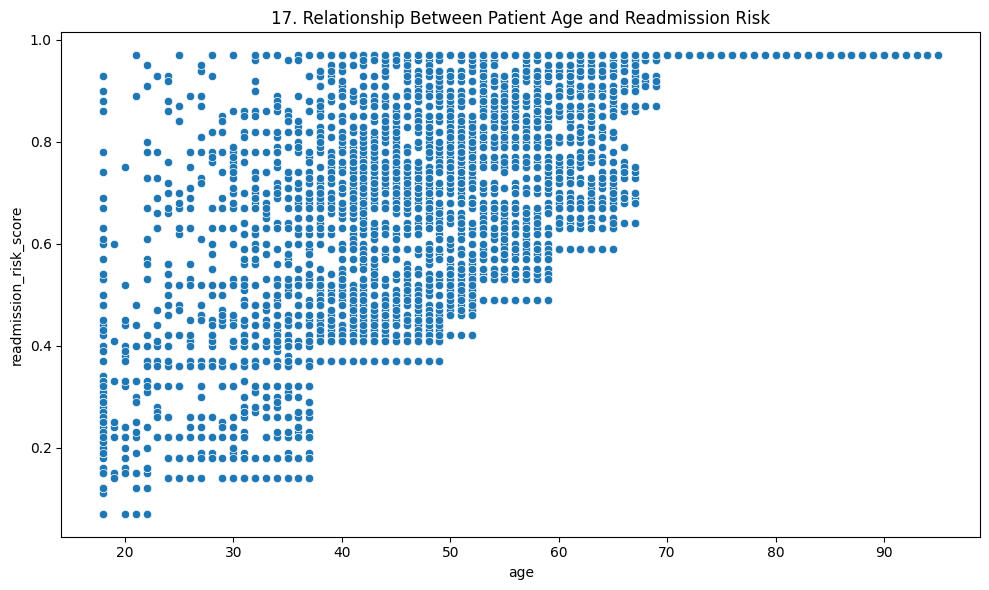

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='readmission_risk_score')
plt.title(f'{plot_no}. Relationship Between Patient Age and Readmission Risk')
show_fig()
plot_no += 1

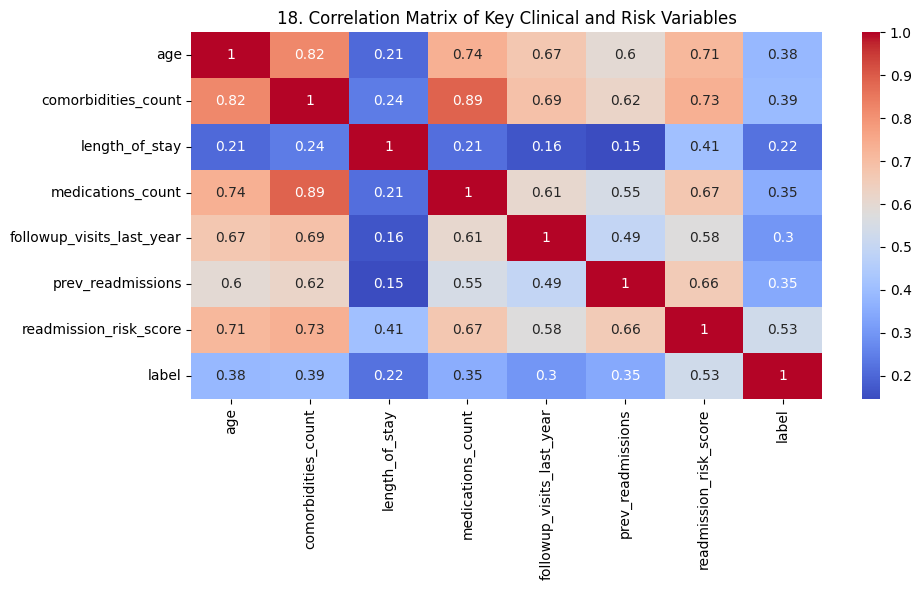

In [30]:
fig = plt.figure(figsize=(10,6))
corr = df[['age','comorbidities_count','length_of_stay','medications_count','followup_visits_last_year','prev_readmissions','readmission_risk_score','label']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Matrix of Key Clinical and Risk Variables')
show_fig()
plot_no += 1

# Model Training

## Drop columns that are not useful for modeling

In [31]:
df_model = df.drop(columns=['patient_id','admission_date'])

## Encode categorical features into numeric values

In [32]:
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

## Separate features and target variable

In [33]:
X = df_model.drop('label', axis=1)
y = df_model['label']

## Split dataset into training and testing sets

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scale feature values to improve model performance

In [35]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train a supervised Logistic Regression model

In [36]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Predict values on the test dataset

In [37]:
y_pred = model.predict(X_test)

## Calculate and print model accuracy

In [38]:
acc = accuracy_score(y_test, y_pred)
print("Model Accuracy:", acc)

Model Accuracy: 0.819375


## Generate confusion matrix

In [39]:
cm = confusion_matrix(y_test, y_pred)

## Plot confusion matrix for Actual vs Predicted results

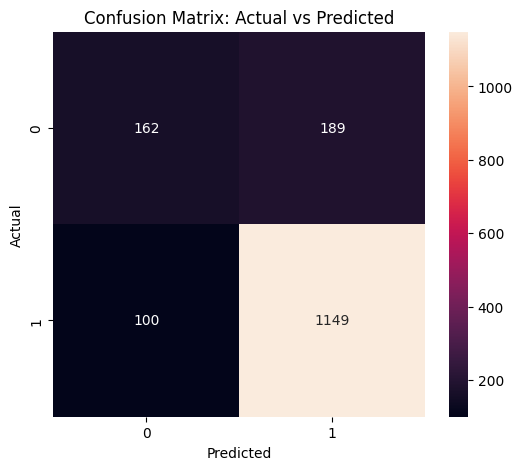

In [40]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Actual vs Predicted")
plt.show()